In [1]:
%pip install -q langchain langchain-community langchain-core langchain-openai langgraph --upgrade
%pip install -q python-dotenv nest_asyncio

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
import nest_asyncio

nest_asyncio.apply()

In [3]:
# pdf -> txt by using Zerox

# from dotenv import load_dotenv
# from langchain_community.document_loaders.pdf import ZeroxPDFLoader

# load_dotenv()

# loader = ZeroxPDFLoader(
#     file_path="./real_estate_tax.pdf",
#     model="gpt-4.1-mini",
# )

# pages = loader.load()

In [4]:
# print(f"total pages: {len(pages)}")
# print(pages[0].page_content[:500])

In [5]:
# create real_estate_tax.txt

# with open("real_estate_tax.txt", "w") as f:
#     for page in pages:
#         f.write(page.page_content + "\n\n")

In [6]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph


class AgentState(TypedDict):
    query: str  # user question
    answer: str  # ai answer (세율)
    tax_base_equation: str  # 과세표준 계산 수식
    tax_deduction: str  # 공제액
    market_ratio: str  # 공정시장가액비율
    tax_base: str  # 과세표준 계산


graph_builder = StateGraph(AgentState)

In [ ]:
# 이미 split 한번 했기 때문에 다시 실행할 때 주석처리

# from langchain_text_splitters import RecursiveCharacterTextSplitter
# from langchain_community.document_loaders import TextLoader

# text_splitter = RecursiveCharacterTextSplitter(chunk_size=1500, chunk_overlap=200)

# text_path = "./real_estate_tax.txt"
# loader = TextLoader(text_path)
# document_list = loader.load_and_split(text_splitter)

In [ ]:
from langchain_chroma import Chroma
from langchain_openai import OpenAIEmbeddings

embedding_function = OpenAIEmbeddings(model="text-embedding-3-large")

# 처음 실행할 때 (처음 db에 embedding)
# vector_store = Chroma.from_documents(
#     documents=document_list,
#     embedding=embedding_function,
#     collection_name="real_estate_tax",
#     persist_directory="./real_estate_tax_collection",
# )

# embedding 되어있는 db 불러오기
vector_store = Chroma(
    embedding_function=embedding_function,
    collection_name="real_estate_tax",
    persist_directory="./real_estate_tax_collection",
)

retriever = vector_store.as_retriever(search_kwargs={"k": 3})

In [9]:
# 질문에 따라 dynamic하게 retrieval 가능
query = "5억짜리 집 1채, 10억짜리 집 1채, 20억짜리 집 1채를 가지고 있을 때, 세금을 얼마나 내나요?"

In [10]:
from langchain_openai import ChatOpenAI
from langsmith import Client
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnablePassthrough
from langchain_core.prompts import ChatPromptTemplate

client = Client()
rag_prompt = client.pull_prompt("rlm/rag-prompt", dangerously_pull_public_prompt=True)

llm = ChatOpenAI(model="gpt-4o")
small_llm = ChatOpenAI(model="gpt-4o-mini")

In [11]:
# 과세표준 구하는 과정

tax_base_retrieval_chain = (
    {"context": retriever, "question": RunnablePassthrough()}
    | rag_prompt
    | llm
    | StrOutputParser()
)

tax_base_equation_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "사용자의 질문에서 과세표준을 계산하는 방법을 수식으로 나타내주세요. 부연설명 없이 수식만 나타내주세요.",
        ),
        ("human", "{tax_base_equation_information}"),
    ]
)

tax_base_equation_chain = (
    {"tax_base_equation_information": RunnablePassthrough()}
    | tax_base_equation_prompt
    | llm
    | StrOutputParser()
)

tax_base_chain = {
    "tax_base_equation_information": tax_base_retrieval_chain
} | tax_base_equation_chain


def get_tax_bsae_equation(state: AgentState):
    tax_base_equation_question = "주택에 대한 종합부동산세 계산시 과세표준을 계산하는 방법을 수식으로 표현해서 알려주세요"
    tax_base_equation = tax_base_chain.invoke(tax_base_equation_question)
    return {"tax_base_equation": tax_base_equation}

In [12]:
# get_tax_bsae_equation({})
# {'tax_base_equation': '과세표준 = max(0, (공시가격 합계 - 공제금액) × 공정시장가격비율)'}

In [13]:
# 공제액 구하는 과정

tax_deduction_chain = (
    {"context": retriever, "question": RunnablePassthrough()}
    | rag_prompt
    | llm
    | StrOutputParser()
)


def get_tax_deduction(state: AgentState):
    tax_deduction_question = "주택에 대한 종합 부동산세 계산시 공제금액을 알려주세요"
    tax_deduction = tax_deduction_chain.invoke(tax_deduction_question)
    return {"tax_deduction": tax_deduction}

In [14]:
get_tax_deduction({})
# {'tax_deduction': '주택에 대한 종합부동산세 계산 시 공제 금액은, 1세대 1주택자의 경우 공시가격에서 12억 원을 공제합니다. 1세대 1주택자가 아닌 다른 경우에는 9억 원을 공제합니다. 세부적인 공제 사항은 연령이나 소유 주택 수에 따라 다를 수 있습니다.'}

{'tax_deduction': '주택에 대한 종합부동산세 공제금액은 1세대 1주택자의 경우 12억원, 그 외의 경우 9억원입니다.'}

In [15]:
# %pip install -U langchain-tavily

In [16]:
# 공정시장가액비율 구하는 과정 -> 대통령령 -> 즉 web search가 필요하다.

from langchain_tavily import TavilySearch
from datetime import date

tavily_search_tool = TavilySearch(
    max_results=5,
    search_depth="advanced",
    include_answer=True,
    include_raw_content=True,
    include_images=True,
)

tax_market_ratio_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            f"아래 정보를 기반으로 공정시장 가액비율을 계산해주세요\n\nContext:\n{{context}}",
        ),
        ("human", "{query}"),
    ]
)


def get_market_ratio(state: AgentState):
    query = f"오늘 날짜:({date.today()})에 해당하는주택 공시가격 공정시장가액비율은 몇%인가요?"
    context = tavily_search_tool.invoke(query)
    print(f"context == {context}")
    tax_market_ratio_chain = tax_market_ratio_prompt | llm | StrOutputParser()
    market_ratio = tax_market_ratio_chain.invoke({"context": context, "query": query})
    return {"market_ratio": market_ratio}

In [17]:
# get_market_ratio({})
# {'market_ratio': '2026년 주택 공시가격의 공정시장가액비율은 공시가격에 따라 다릅니다:1주택자 재산세 \n- 공시가격 3억원 이하: 43%\n- 공시가격 3억원 초과 6억원 이하: 44%\n- 공시가격 6억원 초과: 45% \n\n, 종합부동산세 및 다주택자 재산세: \n 일괄적으로 60% 적용 \n\n이 비율은 재산세 과세표준을 산정할 때 적용됩니다.'}

In [18]:
from langchain_core.prompts import PromptTemplate

# tax_base_calculation_prompt = PromptTemplate.from_template("""
# 주어진 내용을 기반으로 과세표준을 계산해주세요.

# 과제표준 계산 공식: {tax_base_equation}
# 공제금액: {tax_deduction}
# 공정시장가액비율" {market_ratio}
# 사용자 주택 공시가격 정보" {query}
# """)

tax_base_calculation_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            """주어진 내용을 기반으로 과세표준을 계산해주세요.
         과제표준 계산 공식: {tax_base_equation}
         공제금액: {tax_deduction}
         공정시장가액비율" {market_ratio}
         사용자 주택 공시가격 정보" {query}
         """,
        ),
        ("human", "사용자 주택 공시가격 정보: {query}"),
    ]
)


def calculate_tax_base(state: AgentState):
    tax_base_equation = state["tax_base_equation"]
    tax_deduction = state["tax_deduction"]
    market_ratio = state["market_ratio"]
    query = state["query"]
    tax_base_calculation_chain = tax_base_calculation_prompt | llm | StrOutputParser()
    tax_base = tax_base_calculation_chain.invoke(
        {
            "tax_base_equation": tax_base_equation,
            "tax_deduction": tax_deduction,
            "market_ratio": market_ratio,
            "query": query,
        }
    )
    print(f"tax_base == {tax_base}")
    return {"tax_base": tax_base}

In [19]:
initial_state = {
    "query": query,
    "tax_base_equation": "과세표준 = max(0, (공시가격 합계 - 공제금액) × 공정시장가격비율)",
    "tax_deduction": "주택에 대한 종합부동산세 계산 시 공제 금액은, 1세대 1주택자의 경우 공시가격에서 12억 원을 공제합니다. 1세대 1주택자가 아닌 다른 경우에는 9억 원을 공제합니다. 세부적인 공제 사항은 연령이나 소유 주택 수에 따라 다를 수 있습니다.",
    "market_ratio": "2026년 주택 공시가격의 공정시장가액비율은 공시가격에 따라 다릅니다:1주택자 재산세 \n- 공시가격 3억원 이하: 43%\n- 공시가격 3억원 초과 6억원 이하: 44%\n- 공시가격 6억원 초과: 45% \n\n, 종합부동산세 및 다주택자 재산세: \n 일괄적으로 60% 적용 \n\n이 비율은 재산세 과세표준을 산정할 때 적용됩니다.",
}

In [20]:
calculate_tax_base(initial_state)

tax_base == 이 사용자에게 주어진 정보에 따르면, 총 3채의 주택을 소유하고 있으며, 각각의 공시가격은 5억 원, 10억 원, 20억 원입니다. 이 경우 세금을 계산하기 위해서는 각각의 항목에 대한 과세표준을 계산해야 합니다. 여기서는 세금 계산에 필요한 요소들의 총합을 계산합니다:

1. **종합부동산세 과세표준 계산**:

   사용자 공시가격의 총합: 5억 + 10억 + 20억 = 35억 원

   공제금액: 다주택자이므로 9억 원 공제

   과세표준 = max(0, (35억 - 9억) × 60%)

   과세표준 = (26억 × 60%) = 15.6억 원

이렇게 계산된 과세표준에 따라 종합부동산세율을 적용하여 최종 세금을 납부합니다. 하지만 이 예제에서는 과세표준까지만 계산한 것으로, 실제 세금은 세율과 기타 요인들(예를 들면 연령이나 보유 기간에 따른 공제 등)이 추가로 고려되어야 합니다.

원하신다면, 추가 세율 정보나 구체적인 세율을 제공해 주시면 더욱 자세한 세금 계산을 도와드릴 수 있습니다.


{'tax_base': '이 사용자에게 주어진 정보에 따르면, 총 3채의 주택을 소유하고 있으며, 각각의 공시가격은 5억 원, 10억 원, 20억 원입니다. 이 경우 세금을 계산하기 위해서는 각각의 항목에 대한 과세표준을 계산해야 합니다. 여기서는 세금 계산에 필요한 요소들의 총합을 계산합니다:\n\n1. **종합부동산세 과세표준 계산**:\n\n   사용자 공시가격의 총합: 5억 + 10억 + 20억 = 35억 원\n\n   공제금액: 다주택자이므로 9억 원 공제\n\n   과세표준 = max(0, (35억 - 9억) × 60%)\n\n   과세표준 = (26억 × 60%) = 15.6억 원\n\n이렇게 계산된 과세표준에 따라 종합부동산세율을 적용하여 최종 세금을 납부합니다. 하지만 이 예제에서는 과세표준까지만 계산한 것으로, 실제 세금은 세율과 기타 요인들(예를 들면 연령이나 보유 기간에 따른 공제 등)이 추가로 고려되어야 합니다.\n\n원하신다면, 추가 세율 정보나 구체적인 세율을 제공해 주시면 더욱 자세한 세금 계산을 도와드릴 수 있습니다.'}

In [21]:
tax_rate_calculation_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            """당신은 종합부동산세 계산 전문가 입니다. 아래 문서를 참고해서 사용자의 질문에 대한 종합부동산세를 계산해주세요
     종합부동산세 세율:{context}
     """,
        ),
        (
            "human",
            """과세표준과 사용자가 소지한 주택의 수가 아래와 같을 때 종합부동산세를 계산해주세요
     과세표준: {tax_base}
     주택수: {query}""",
        ),
    ]
)


def calculate_tax_rate(state: AgentState):
    query = state["query"]
    tax_base = state["tax_base"]
    context = retriever.invoke(query)
    tax_rate_chain = tax_rate_calculation_prompt | llm | StrOutputParser()
    tax_rate = tax_rate_chain.invoke(
        {"context": context, "tax_base": tax_base, "query": query}
    )
    print(f"tax_rate == {tax_rate}")
    return {"answer": tax_rate}

In [22]:
calculate_tax_base(initial_state)

tax_base == 사용자의 주택 공시가격 정보는 5억 원, 10억 원, 20억 원짜리 집 각각 1채를 소유하고 있는 경우입니다. 이 정보를 바탕으로 과세표준을 계산해 보겠습니다.

1. **공시가격 합계**: 
   - 5억 원 + 10억 원 + 20억 원 = 35억 원

2. **공제금액**:
   - 1세대 1주택자가 아니므로, 총 공시가격에서 9억 원을 공제합니다.

3. **과세표준 계산**:
   \[
   \text{과세표준} = \max(0, (35억 원 - 9억 원) \times 0.60) 
   \]
   \[
   \text{과세표준} = \max(0, 26억 원 \times 0.60) 
   \]
   \[
   \text{과세표준} = \max(0, 15억 6천만 원) 
   \]
   \[
   \text{과세표준} = 15억 6천만 원
   \]

따라서, 사용자의 종합부동산세를 계산할 때 적용할 과세표준은 15억 6천만 원입니다. 종합부동산세율에 따라 최종 세액이 결정되지만, 정확한 세율 정보 없이 여기까지 계산할 수 있습니다. 세율은 연도와 세법에 따라 변동될 수 있으므로, 구체적인 세액은 해당 연도의 세법을 참조해야 합니다.


{'tax_base': '사용자의 주택 공시가격 정보는 5억 원, 10억 원, 20억 원짜리 집 각각 1채를 소유하고 있는 경우입니다. 이 정보를 바탕으로 과세표준을 계산해 보겠습니다.\n\n1. **공시가격 합계**: \n   - 5억 원 + 10억 원 + 20억 원 = 35억 원\n\n2. **공제금액**:\n   - 1세대 1주택자가 아니므로, 총 공시가격에서 9억 원을 공제합니다.\n\n3. **과세표준 계산**:\n   \\[\n   \\text{과세표준} = \\max(0, (35억 원 - 9억 원) \\times 0.60) \n   \\]\n   \\[\n   \\text{과세표준} = \\max(0, 26억 원 \\times 0.60) \n   \\]\n   \\[\n   \\text{과세표준} = \\max(0, 15억 6천만 원) \n   \\]\n   \\[\n   \\text{과세표준} = 15억 6천만 원\n   \\]\n\n따라서, 사용자의 종합부동산세를 계산할 때 적용할 과세표준은 15억 6천만 원입니다. 종합부동산세율에 따라 최종 세액이 결정되지만, 정확한 세율 정보 없이 여기까지 계산할 수 있습니다. 세율은 연도와 세법에 따라 변동될 수 있으므로, 구체적인 세액은 해당 연도의 세법을 참조해야 합니다.'}

In [23]:
tax_base_state = {
    "tax_base": "주어진 정보를 바탕으로 주택 공시가격의 합계, 공제금액, 공정시장가액비율을 통해 종합부동산세 과세표준을 계산해보겠습니다. \n\n1. **공시가격 합계**: 5억 + 10억 + 20억 = 35억 원\n\n2. **공제금액**:\n   - 사용자가 1세대 1주택자가 아닐 경우: 9억 원\n\n3. **과세표준 계산**:\n   - 과세표준 = max(0, (35억 - 9억) × 60%)\n   - 과세표준 = max(0, 26억 × 0.6)\n   - 과세표준 = max(0, 15.6억 원)\n\n따라서, 종합부동산세의 과세표준은 15.6억 원입니다. \n\n실제 세금액을 계산하기 위해서는 추가적인 정보가 필요합니다. 예를 들어, 과세표준에 따라 정해진 세율에 기반하여 정확한 세금액을 산출해야 합니다. 해당 세율은 법령에 의거하며, 연령 및 소유 주택 수에 따라 차이가 있을 수 있습니다. 정확한 세금액을 알고 싶다면, 국세청 또는 관련 세무 서비스에서 확인하시기를 권장드립니다.",
    "query": query,
}

In [24]:
calculate_tax_rate(tax_base_state)

tax_rate == 사용자가 3채의 주택을 소유하고 있으며, 과세표준이 15.6억 원인 상황에서 종합부동산세를 계산해보겠습니다. 사용자가 3주택 이상을 소유하므로 이에 따라 적용되는 세율을 사용하게 됩니다.

1. **과세표준**: 15.6억 원

2. **세율** (3주택 이상 소유 경우):
   - 6억 원 초과 12억 원 이하: 960만원 + (12억 원 초과 금액의 1천분의 20)
   - 12억 원 초과 25억 원 이하: 해당 세율은 적용되지 않음

3. **종합부동산세 계산**:
   - 15.6억 원은 6억 원 초과 12억 원 이하 구간과 12억 원 초과 구간에 해당합니다.
   - 6억 원 초과 12억 원 이하: 960만원
   - 초과 금액 계산: (15.6억 원 - 12억 원) × (1천분의 20)
   - 초과 금액 세액: 3.6억 원 × 0.002 = 720만원
   - 총 종합부동산세: 960만원 + 720만원 = 1,680만원

따라서 사용자는 1,680만원의 종합부동산세를 납부해야 합니다.


{'answer': '사용자가 3채의 주택을 소유하고 있으며, 과세표준이 15.6억 원인 상황에서 종합부동산세를 계산해보겠습니다. 사용자가 3주택 이상을 소유하므로 이에 따라 적용되는 세율을 사용하게 됩니다.\n\n1. **과세표준**: 15.6억 원\n\n2. **세율** (3주택 이상 소유 경우):\n   - 6억 원 초과 12억 원 이하: 960만원 + (12억 원 초과 금액의 1천분의 20)\n   - 12억 원 초과 25억 원 이하: 해당 세율은 적용되지 않음\n\n3. **종합부동산세 계산**:\n   - 15.6억 원은 6억 원 초과 12억 원 이하 구간과 12억 원 초과 구간에 해당합니다.\n   - 6억 원 초과 12억 원 이하: 960만원\n   - 초과 금액 계산: (15.6억 원 - 12억 원) × (1천분의 20)\n   - 초과 금액 세액: 3.6억 원 × 0.002 = 720만원\n   - 총 종합부동산세: 960만원 + 720만원 = 1,680만원\n\n따라서 사용자는 1,680만원의 종합부동산세를 납부해야 합니다.'}

In [25]:
graph_builder.add_node("get_tax_base_equation", get_tax_bsae_equation)
graph_builder.add_node("get_tax_deduction", get_tax_deduction)
graph_builder.add_node("get_market_ratio", get_market_ratio)
graph_builder.add_node("calculate_tax_base", calculate_tax_base)
graph_builder.add_node("calculate_tax_rate", calculate_tax_rate)

In [29]:
from langgraph.graph import START, END

graph_builder.add_edge(START, "get_tax_base_equation")
graph_builder.add_edge(START, "get_tax_deduction")
graph_builder.add_edge(START, "get_market_ratio")
graph_builder.add_edge("get_tax_base_equation", "calculate_tax_base")
graph_builder.add_edge("get_tax_deduction", "calculate_tax_base")
graph_builder.add_edge("get_market_ratio", "calculate_tax_base")
graph_builder.add_edge("calculate_tax_base", "calculate_tax_rate")
graph_builder.add_edge("calculate_tax_rate", END)

Adding an edge to a graph that has already been compiled. This will not be reflected in the compiled graph.
Adding an edge to a graph that has already been compiled. This will not be reflected in the compiled graph.
Adding an edge to a graph that has already been compiled. This will not be reflected in the compiled graph.
Adding an edge to a graph that has already been compiled. This will not be reflected in the compiled graph.
Adding an edge to a graph that has already been compiled. This will not be reflected in the compiled graph.
Adding an edge to a graph that has already been compiled. This will not be reflected in the compiled graph.
Adding an edge to a graph that has already been compiled. This will not be reflected in the compiled graph.
Adding an edge to a graph that has already been compiled. This will not be reflected in the compiled graph.


In [30]:
graph = graph_builder.compile()

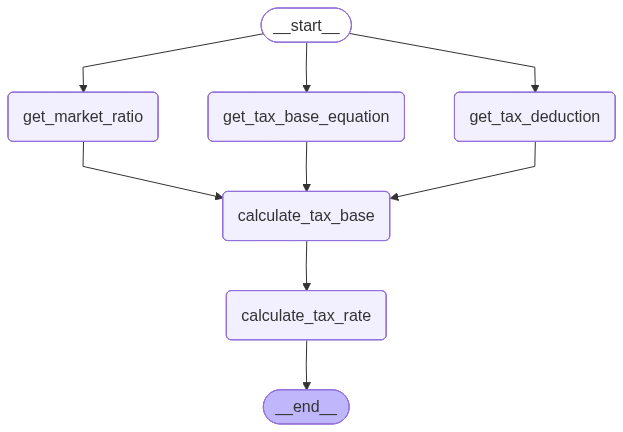

In [31]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [32]:
initial_state = {"query": query}
graph.invoke(initial_state)

context == {'query': '오늘 날짜:(2026-05-19)에 해당하는주택 공시가격 공정시장가액비율은 몇%인가요?', 'follow_up_questions': None, 'answer': 'As of 2026-05-19, the public real estate assessment rate is 60%. This rate determines the taxable standard for property taxes. The rate was set to 60% starting from 2025.', 'images': ['https://drkjaf.com/wp-content/uploads/2026/03/featured-804.jpg', 'https://on-estate.com/wp-content/uploads/2026/03/%EC%A0%9C%EB%AA%A9%EC%9D%84-%EC%9E%85%EB%A0%A5%ED%95%B4%EC%A3%BC%EC%84%B8%EC%9A%94.-13-1024x724.jpg', 'https://scs-phinf.pstatic.net/MjAyNjAzMjBfMTMw/MDAxNzc0MDA4NDQwNTIz.BOcgrmJeOKlu-kkmEJ2iUPJCy6Jj6dDM4lm3C3hiNfcg.EhCOn8JC85JZu7ZCdq4oXWCGLU6pD1h3zg7bWo-oxTEg.PNG/image.png?type=w800', 'https://i.ytimg.com/vi/VN1Xukw3ICc/hq720.jpg?sqp=-oaymwEhCK4FEIIDSFryq4qpAxMIARUAAAAAGAElAADIQj0AgKJD&rs=AOn4CLBs7k7PxORxNAkftoOjgi6sTSnmyg', 'https://mblogthumb-phinf.pstatic.net/MjAyNTAzMDZfMjU1/MDAxNzQxMjA5NzE0MTI3.yjvDGrS5xiH4fyDyePIh2e2b3MPgLCUEHcVtXXnSJ7cg.75H1A46b_weyUYG1zwwo30qQid4SRPppJJMw

{'query': '5억짜리 집 1채, 10억짜리 집 1채, 20억짜리 집 1채를 가지고 있을 때, 세금을 얼마나 내나요?',
 'answer': '사용자가 소유한 주택이 총 3채이므로, \'납세의무자가 3주택 이상을 소유한 경우\'의 세율을 적용해야 합니다. 과세표준은 15.6억 원입니다. 다음 단계에 따라 세금을 계산하겠습니다.\n\n1. **과세표준에 적용되는 세율 찾기:**\n\n   과세표준 15.6억 원에 해당하는 구간은 "12억원 초과 25억원 이하"입니다. \n\n   - **세율 공식**: 960만원 + (초과 금액 × 1천분의 20)\n\n2. **세금 계산:**\n\n   과세표준 15.6억 원에서 12억 원을 초과하는 금액은 3.6억 원입니다. 이를 공식에 대입합니다:\n\n   \\[\n   960만원 + (3.6억 × 0.002) = 960만원 + 720만원 = 1,680만원\n   \\]\n\n따라서 주어진 조건에서 납부해야 할 종합부동산세는 **1,680만 원**입니다.',
 'tax_base_equation': '\\((\\text{공시가격 총합} - \\text{공제금액}) \\times \\text{공정시장가격비율}\\)',
 'tax_deduction': '1세대 1주택자의 경우 종합부동산세 계산시 공제금액은 12억원입니다. 1세대 1주택자에 해당하지 않는 경우에는 9억원이 공제됩니다. 법인이나 법인으로 보는 단체의 경우에는 공제가 없습니다.',
 'market_ratio': '2026년 5월 19일 기준으로 주택 공시가격에 대한 공정시장가액비율은 60%입니다.',
 'tax_base': '주어진 정보를 바탕으로 과세표준을 계산해보겠습니다. \n\n1. 주택 공시가격 총합: 5억 + 10억 + 20억 = 35억 원\n2. 공제금액: 1세대 1주택자가 아닌 경우에는 9억 원이 공제됩니다.\n3. 공정시장가액비율: 60%\n\n과세표준 계산:\n\\[\n(\\text{공시가격 총합} - \\text{공제금액}) \\times \